# MCDI504 — Machine Learning I
# Avance del Proyecto — Fase 3: Desarrollo del Proyecto
## Implementación de Modelos de Clasificación Supervisada mediante Redes Neuronales
### Notebook F3_RedesNeuronales.ipynb

**Curso:** MCDI504 - Machine Learning I
**Grupo:** 5

**Integrantes:**
- Arturo Knopke Vera
- Nicolás Soletic Cobos
- Sebastián Navarrete Soto
- Roberto Moncada González

**Fecha:** 22 de agosto de 2026

---

**Índice**
1. [Contexto y objetivo de la Fase 3](#1)
2. [Librerías necesarias](#2)
3. [Carga del conjunto de datos](#3)
4. [Descripción del dataset y preparación para redes neuronales](#4)
5. [Análisis exploratorio inicial y preparación de datos](#5)
6. [Red neuronal con una capa oculta](#6)
7. [Red neuronal con dos capas ocultas](#7)
8. [Red neuronal con tres capas ocultas](#8)
9. [Evaluación de desempeño de redes neuronales](#9)
10. [Comparación de arquitecturas de redes neuronales](#10)
11. [Conclusiones](#11)
12. [Referencias](#12)


<a id="1"></a>
## 1. Contexto y objetivo de la Fase 3

En la **Fase 1** (`F1_Definicion.ipynb`), NextWork Advisory definió el problema de negocio de estimar el riesgo de automatización de cargos hacia 2030 a partir del dataset **AI Impact on Jobs 2030**, y justificó un enfoque de **clasificación supervisada multiclase** sobre la variable ordinal `Risk_Category` (`Low`/`Medium`/`High`). En la **Fase 2** (`F2_Regresion.ipynb`) se exploró la alternativa de regresión sobre `Automation_Probability_2030`, y se encontró evidencia clave para el preprocesamiento: el cargo (`Job_Title`) explica por sí solo ~86% de la varianza de la variable objetivo continua, muy por encima del resto de las variables numéricas/ordinales del dataset.

La **Fase 3** (RA3) retoma el problema de clasificación original planteado en la Fase 1 —predecir `Risk_Category`— y exige implementar y comparar **redes neuronales superficiales (MLP)** con una, dos y tres capas ocultas, evaluando su desempeño mediante matrices de confusión y métricas de clasificación. En consecuencia, este notebook:

- Retoma el mismo dataset y el mismo criterio de selección de variables validado en la Fase 2 (incluyendo `Job_Title` mediante codificación *dummy*, dado su poder predictivo demostrado), aplicado ahora al problema de clasificación de la Fase 1.
- Prepara los datos para el modelamiento mediante redes neuronales (partición entrenamiento/prueba y escalado).
- Implementa y entrena tres arquitecturas de **`MLPClassifier`**: una, dos y tres capas ocultas, documentando en cada caso una ficha técnica breve con los parámetros mínimos utilizados.
- Evalúa cada modelo mediante matriz de confusión y las métricas *accuracy*, *precision*, *recall* y *F1-score* sobre el conjunto de prueba.
- Compara las tres arquitecturas y fundamenta una conclusión orientada a la toma de decisiones de NextWork Advisory.


<a id="2"></a>
## 2. Librerías necesarias

Importamos las librerías para manipulación de datos, visualización, preprocesamiento, el modelo de red neuronal (`MLPClassifier`) y las métricas de evaluación para clasificación.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Paleta categórica fija (orden fijo por modelo, consistente en todo el notebook)
COLOR_1CAPA = "#2a78d6"    # azul
COLOR_2CAPAS = "#eb6834"   # naranjo
COLOR_3CAPAS = "#1baf7a"   # aqua
COLORES_RIESGO = {"Low": "#0ca30c", "Medium": "#fab219", "High": "#d03b3b"}

sns.set_style("whitegrid")
RANDOM_STATE = 42

<a id="3"></a>
## 3. Carga del conjunto de datos

Se reutiliza el mismo dataset **AI Impact on Jobs 2030** de las Fases 1 y 2, disponible en el repositorio del proyecto (`../data/AI_Impact_on_Jobs_2030.csv`), asegurando coherencia entre las tres fases.

In [2]:
df = pd.read_csv("../data/AI_Impact_on_Jobs_2030.csv")

print(f"Dimensiones del dataset: {df.shape}")
display(df.head())

Dimensiones del dataset: (3000, 18)


,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


<a id="4"></a>
## 4. Descripción del dataset y preparación para redes neuronales

### 4.1 Descripción general del dataset

El dataset contiene **3.000 observaciones** (perfiles laborales) y **18 columnas**: el cargo (`Job_Title`, 20 categorías), variables numéricas de perfil (`Average_Salary`, `Years_Experience`), el nivel educativo (`Education_Level`, ordinal), dos índices de contexto (`AI_Exposure_Index`, `Tech_Growth_Factor`), diez puntajes de habilidades (`Skill_1`–`Skill_10`, escala 0-1) y dos variables de resultado: `Automation_Probability_2030` (continua, 0-1) y `Risk_Category` (categórica ordinal, derivada de la anterior por corte de umbrales).

### 4.2 Variable objetivo y variables predictoras

- **Variable objetivo (target):** `Risk_Category` — variable categórica ordinal con tres clases (`Low`, `Medium`, `High`), la misma variable de decisión definida en la Fase 1. El problema corresponde a una **clasificación supervisada multiclase**.
- **Variables predictoras candidatas:** `Average_Salary`, `Years_Experience`, `Education_Level`, `AI_Exposure_Index`, `Tech_Growth_Factor`, `Skill_1`–`Skill_10` y `Job_Title`.
- **Variable excluida del conjunto de predictores:** `Automation_Probability_2030`. Esta variable es la que da origen a `Risk_Category` mediante un corte directo por umbrales (`Low`: 0.05-0.30, `Medium`: 0.31-0.70, `High`: 0.71-0.95, según se documentó en la Fase 1); incluirla como predictor constituiría una **fuga de información (data leakage)**, de forma análoga a como en la Fase 2 se excluyó `Risk_Category` del conjunto de predictores para el problema de regresión.

### 4.3 Selección y codificación de variables

Se replica el criterio de selección de variables validado en la Fase 2, que mostró evidencia cuantitativa de que `Job_Title` concentra la mayor parte de la señal predictiva del dataset (~86% de la varianza de `Automation_Probability_2030` explicada solo por el promedio de cada cargo):

- **`Education_Level`** se codifica de forma ordinal (`High School`=1 < `Bachelor's`=2 < `Master's`=3 < `PhD`=4), igual que en las Fases 1 y 2.
- **`Job_Title`** se incorpora mediante codificación *dummy* (`pd.get_dummies`, con `drop_first=True`), generando 19 columnas binarias sobre las 20 categorías del cargo. La codificación dummy difiere de un one-hot puro en que omite una categoría de referencia (`AI Engineer`) para evitar una columna redundante: con *k*=20 categorías se generan *k*−1=19 columnas, en vez de las 20 columnas de un one-hot completo.
- Las variables numéricas continuas (`Average_Salary`, `Years_Experience`, `AI_Exposure_Index`, `Tech_Growth_Factor`, `Skill_1`–`Skill_10`) se mantienen sin transformación adicional en esta etapa; su escalado se aplica más adelante (sección 4.5), de forma conjunta con las dummies de `Job_Title`.

El conjunto final de **34 variables predictoras** queda compuesto por 15 variables numéricas/ordinales (`Average_Salary`, `Years_Experience`, `Education_Level_Num`, `AI_Exposure_Index`, `Tech_Growth_Factor`, `Skill_1`–`Skill_10`) más las **19 columnas dummy de `Job_Title`**.

In [3]:
orden_educacion = {"High School": 1, "Bachelor's": 2, "Master's": 3, "PhD": 4}
df["Education_Level_Num"] = df["Education_Level"].map(orden_educacion)

variables_numericas = (
    ["Average_Salary", "Years_Experience", "Education_Level_Num",
     "AI_Exposure_Index", "Tech_Growth_Factor"]
    + [f"Skill_{i}" for i in range(1, 11)]
)

job_title_dummies = pd.get_dummies(df["Job_Title"], prefix="Job_Title", drop_first=True).astype(int)

X = pd.concat([df[variables_numericas], job_title_dummies], axis=1)
y = df["Risk_Category"]

categoria_referencia = sorted(df["Job_Title"].unique())[0]
print(f"Variables numéricas/ordinales: {len(variables_numericas)}")
print(f"Columnas dummy de Job_Title: {job_title_dummies.shape[1]} (categoría de referencia: '{categoria_referencia}')")
print(f"\nDimensiones de X (predictoras): {X.shape}")
print(f"Dimensiones de y (variable objetivo): {y.shape}")

Variables numéricas/ordinales: 15
Columnas dummy de Job_Title: 19 (categoría de referencia: 'AI Engineer')

Dimensiones de X (predictoras): (3000, 34)
Dimensiones de y (variable objetivo): (3000,)


### 4.4 Partición entrenamiento/prueba

Se divide el dataset en un 80% para entrenamiento y un 20% para prueba, usando `random_state=42` para reproducibilidad. Dado que `Risk_Category` no está perfectamente balanceada (`Medium` concentra ~50,7% de los casos, mientras que `Low` y `High` se reparten el resto en partes similares, según se documentó en la Fase 1), se utiliza el parámetro `stratify=y` para asegurar que ambos conjuntos conserven la misma proporción de clases que el dataset completo.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test:  {X_test.shape}")

print("\nDistribución de clases en y_train (proporción):")
print(y_train.value_counts(normalize=True).round(4))
print("\nDistribución de clases en y_test (proporción):")
print(y_test.value_counts(normalize=True).round(4))

Dimensiones de X_train: (2400, 34)
Dimensiones de X_test:  (600, 34)

Distribución de clases en y_train (proporción):
Risk_Category
Medium    0.5071
High      0.2467
Low       0.2462
Name: proportion, dtype: float64

Distribución de clases en y_test (proporción):
Risk_Category
Medium    0.5067
Low       0.2467
High      0.2467
Name: proportion, dtype: float64


### 4.5 Escalado de variables: justificación para redes neuronales

Las variables predictoras presentan escalas muy distintas (`Average_Salary` en decenas de miles de dólares versus índices, habilidades y dummies de `Job_Title` entre 0 y 1), tal como se identificó en la Fase 1. Las redes neuronales entrenadas mediante descenso de gradiente (como el optimizador `adam` utilizado por `MLPClassifier`) son particularmente sensibles a la escala de los datos de entrada: variables con rangos mucho mayores dominan el cálculo del gradiente y ralentizan o distorsionan la convergencia. Por ello se estandarizan los predictores con `StandardScaler` (media 0, desviación estándar 1), ajustado **únicamente con los datos de entrenamiento** para evitar fuga de información desde el conjunto de prueba, replicando el criterio ya utilizado para el MLP de regresión en la Fase 2.

In [5]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Primeras filas de X_train escalado:")
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())

Primeras filas de X_train escalado:


,Average_Salary,Years_Experience,Education_Level_Num,AI_Exposure_Index,Tech_Growth_Factor,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,...,Job_Title_Marketing Manager,Job_Title_Mechanic,Job_Title_Nurse,Job_Title_Research Scientist,Job_Title_Retail Worker,Job_Title_Security Guard,Job_Title_Software Engineer,Job_Title_Teacher,Job_Title_Truck Driver,Job_Title_UX Researcher
0,-0.547719,0.837069,-0.421714,-1.377783,0.757518,-1.090905,-0.485421,0.527219,-0.942799,-1.085484,...,-0.217072,-0.211757,-0.221249,-0.229416,-0.231421,-0.231421,-0.253578,-0.245093,-0.233413,-0.246047
1,-0.215189,-0.775448,-0.421714,0.028716,0.618052,-1.677383,-0.346390,1.427512,0.846882,0.185085,...,-0.217072,-0.211757,-0.221249,-0.229416,-0.231421,-0.231421,-0.253578,-0.245093,-0.233413,-0.246047
2,-1.405275,1.297789,-1.319774,1.681353,-1.473937,-0.642423,0.314007,0.631099,-1.258625,-0.167850,...,-0.217072,-0.211757,-0.221249,-0.229416,-0.231421,-0.231421,-0.253578,-0.245093,-0.233413,4.064265
3,0.821682,1.182609,0.476346,-0.147096,0.652919,0.461535,0.348765,0.596473,-1.048074,-0.767841,...,-0.217072,-0.211757,-0.221249,-0.229416,4.321126,-0.231421,-0.253578,-0.245093,-0.233413,-0.246047
4,1.484396,-0.660268,-1.319774,0.942941,-0.741741,-1.297898,1.321982,1.185125,-0.697157,-0.697254,...,-0.217072,-0.211757,-0.221249,-0.229416,-0.231421,-0.231421,-0.253578,-0.245093,-0.233413,-0.246047


<a id="5"></a>
## 5. Análisis exploratorio inicial y preparación de datos

### 5.1 Distribución de clases de `Risk_Category`

Revisamos la distribución de la variable objetivo en el dataset completo.

,Frecuencia,Proporción
Risk_Category,,
Low,739,0.2463
Medium,1521,0.5070
High,740,0.2467


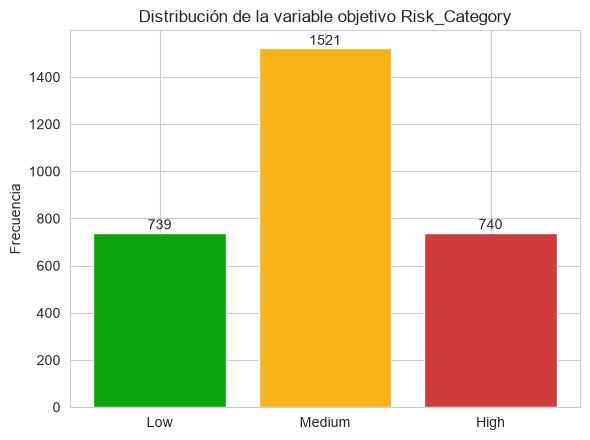

In [6]:
conteo_clases = df["Risk_Category"].value_counts().reindex(["Low", "Medium", "High"])
proporcion_clases = df["Risk_Category"].value_counts(normalize=True).reindex(["Low", "Medium", "High"])

display(pd.DataFrame({"Frecuencia": conteo_clases, "Proporción": proporcion_clases.round(4)}))

plt.figure(figsize=(6, 4.5))
plt.bar(conteo_clases.index, conteo_clases.values,
        color=[COLORES_RIESGO[c] for c in conteo_clases.index])
for i, v in enumerate(conteo_clases.values):
    plt.text(i, v + 15, str(v), ha="center")
plt.title("Distribución de la variable objetivo Risk_Category")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("../figures/f3_distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()

`Risk_Category` presenta un **desequilibrio moderado**: `Medium` concentra 1.521 observaciones (50,7%), mientras que `Low` (739, 24,6%) y `High` (740, 24,7%) se reparten el resto en proporciones casi idénticas entre sí. Este desequilibrio no es severo, pero justifica dos decisiones ya adoptadas: (i) usar `stratify=y` en la partición entrenamiento/prueba (sección 4.4), y (ii) reportar métricas macro-promediadas (que ponderan igual a las tres clases) además del *accuracy*, para no sobrestimar el desempeño del modelo únicamente por acertar bien en la clase mayoritaria (sección 9).

### 5.2 Relación entre `Job_Title` y `Risk_Category`

La Fase 2 mostró que el promedio de `Automation_Probability_2030` por cargo explica ~86% de la varianza de dicha variable continua, agrupándose en tres niveles muy nítidos. Dado que `Risk_Category` se deriva de esa misma variable por corte de umbrales, se espera un patrón equivalente al analizar la proporción de cada clase de riesgo dentro de cada `Job_Title`.

Risk_Category,Low,Medium,High
Job_Title,,,
AI Engineer,1.000,0.000,0.000
Teacher,1.000,0.000,0.000
Software Engineer,0.017,0.983,0.000
Research Scientist,1.000,0.000,0.000
Nurse,1.000,0.000,0.000
Mechanic,0.000,1.000,0.000
Marketing Manager,0.007,0.993,0.000
HR Specialist,0.013,0.987,0.000
Lawyer,0.008,0.992,0.000


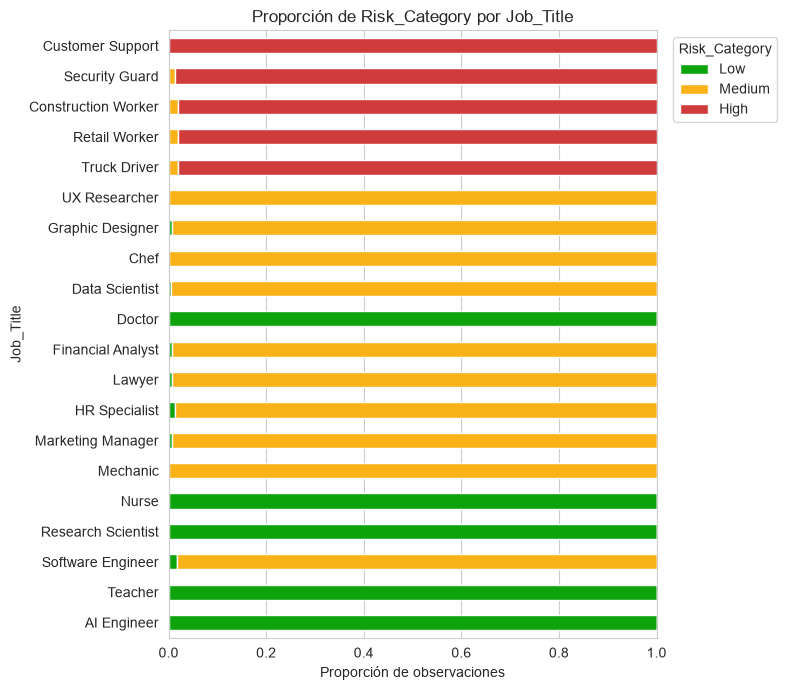

In [7]:
tabla_cruzada = (
    pd.crosstab(df["Job_Title"], df["Risk_Category"], normalize="index")
    .reindex(columns=["Low", "Medium", "High"])
)
tabla_cruzada_ordenada = tabla_cruzada.sort_values("High")

display(tabla_cruzada_ordenada.round(3))

tabla_cruzada_ordenada.plot(
    kind="barh", stacked=True,
    color=[COLORES_RIESGO[c] for c in tabla_cruzada_ordenada.columns],
    figsize=(8, 7)
)
plt.xlabel("Proporción de observaciones")
plt.title("Proporción de Risk_Category por Job_Title")
plt.legend(title="Risk_Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../figures/f3_riesgo_por_cargo.png", dpi=150, bbox_inches="tight")
plt.show()

El gráfico confirma el patrón anticipado: cargos como `AI Engineer`, `Research Scientist`, `Nurse`, `Teacher` y `Doctor` concentran casi exclusivamente observaciones de riesgo `Low`; cargos como `Truck Driver`, `Retail Worker`, `Construction Worker`, `Security Guard` y `Customer Support` concentran casi exclusivamente riesgo `High`; el resto de los cargos se ubica mayoritariamente en riesgo `Medium`. En la práctica, `Job_Title` funciona como un **identificador casi determinístico** de `Risk_Category` en este dataset simulado.

### 5.3 Relación entre la exploración, la preparación de datos y el problema de clasificación

Esta evidencia tiene dos implicancias directas para el modelamiento mediante redes neuronales:

- **Justifica la inclusión de `Job_Title`** (codificado mediante variables *dummy*) como predictor, decisión ya adoptada en la sección 4.3: excluirlo —como en la primera iteración de la Fase 2— privaría a los modelos de la señal predictiva dominante del dataset.
- **Anticipa un desempeño de clasificación muy alto** en las tres arquitecturas de red neuronal que se implementan a continuación (secciones 6 a 8), ya que el problema es, en la práctica, casi linealmente separable una vez incorporado `Job_Title`: no se requiere necesariamente una arquitectura profunda para capturar la relación entre predictores y `Risk_Category`. Esta hipótesis se contrasta empíricamente en la comparación de arquitecturas (sección 10).
- No se identifican valores faltantes ni necesidad adicional de transformación de variables más allá de la codificación (sección 4.3) y el escalado (sección 4.5) ya realizados, consistente con lo documentado en las Fases 1 y 2 para el mismo dataset.

<a id="6"></a>
## 6. Red neuronal con una capa oculta

### 6.1 Descripción de la arquitectura

Se implementa un Perceptrón Multicapa (`MLPClassifier`) con una única capa oculta: una capa de entrada de 34 neuronas (una por variable predictora), una capa oculta de 32 neuronas con activación ReLU, y una capa de salida de 3 neuronas con activación *softmax* (gestionada internamente por `MLPClassifier` para clasificación multiclase), que entrega la probabilidad de cada clase de `Risk_Category`.

**Ficha técnica breve — MLP 1 capa oculta**

| Hiperparámetro | Valor | Propósito |
|---|---|---|
| `hidden_layer_sizes` | (32,) | Una capa oculta de 32 neuronas |
| `activation` | `relu` | Función de activación no lineal en la capa oculta |
| `solver` | `adam` | Algoritmo de optimización basado en descenso de gradiente estocástico |
| `alpha` | 0.001 | Regularización L2, para reducir el sobreajuste |
| `max_iter` | 1000 | Máximo de épocas de entrenamiento |
| `early_stopping` | `True` | Detiene el entrenamiento si no mejora en un conjunto de validación interno |
| `random_state` | 42 | Reproducibilidad |

### 6.2 Evidencia de ejecución en Python

In [8]:
mlp_1capa = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation="relu",
    solver="adam",
    alpha=0.001,
    max_iter=1000,
    random_state=RANDOM_STATE,
    early_stopping=True,
)
mlp_1capa.fit(X_train_scaled, y_train)

y_pred_1capa = mlp_1capa.predict(X_test_scaled)

acc_1capa = accuracy_score(y_test, y_pred_1capa)
prec_1capa = precision_score(y_test, y_pred_1capa, average="macro")
rec_1capa = recall_score(y_test, y_pred_1capa, average="macro")
f1_1capa = f1_score(y_test, y_pred_1capa, average="macro")
cm_1capa = confusion_matrix(y_test, y_pred_1capa, labels=["Low", "Medium", "High"])

print(f"Número de iteraciones hasta convergencia/early stopping: {mlp_1capa.n_iter_}")
print("\n--- Evaluación del modelo MLP (1 capa oculta) ---")
print(f"Accuracy:           {acc_1capa:.4f}")
print(f"Precision (macro):  {prec_1capa:.4f}")
print(f"Recall (macro):     {rec_1capa:.4f}")
print(f"F1-score (macro):   {f1_1capa:.4f}")

print("\nMatriz de confusión (filas=clase real, columnas=clase predicha; orden Low/Medium/High):")
display(pd.DataFrame(cm_1capa,
                      index=["Real Low", "Real Medium", "Real High"],
                      columns=["Pred Low", "Pred Medium", "Pred High"]))

print("\nReporte de clasificación detallado:")
print(classification_report(y_test, y_pred_1capa))

Número de iteraciones hasta convergencia/early stopping: 40

--- Evaluación del modelo MLP (1 capa oculta) ---
Accuracy:           0.9933
Precision (macro):  0.9912
Recall (macro):     0.9956
F1-score (macro):   0.9933

Matriz de confusión (filas=clase real, columnas=clase predicha; orden Low/Medium/High):


,Pred Low,Pred Medium,Pred High
Real Low,148,0,0
Real Medium,0,300,4
Real High,0,0,148



Reporte de clasificación detallado:
              precision    recall  f1-score   support

        High       0.97      1.00      0.99       148
         Low       1.00      1.00      1.00       148
      Medium       1.00      0.99      0.99       304

    accuracy                           0.99       600
   macro avg       0.99      1.00      0.99       600
weighted avg       0.99      0.99      0.99       600



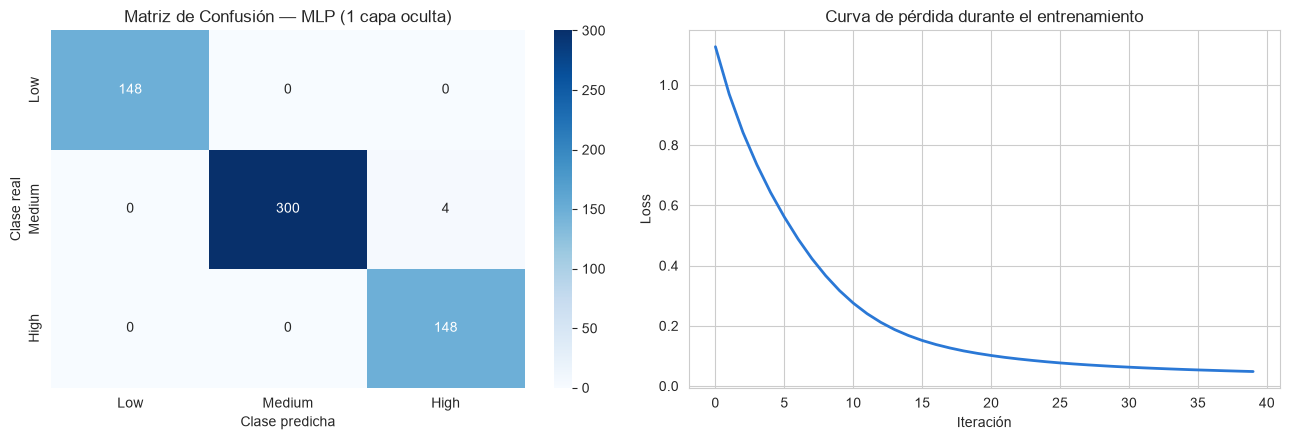

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.heatmap(cm_1capa, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
axes[0].set_title("Matriz de Confusión — MLP (1 capa oculta)")
axes[0].set_xlabel("Clase predicha")
axes[0].set_ylabel("Clase real")

axes[1].plot(mlp_1capa.loss_curve_, color=COLOR_1CAPA, linewidth=2)
axes[1].set_title("Curva de pérdida durante el entrenamiento")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.savefig("../figures/f3_mlp_1capa.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.3 Interpretación del desempeño

El modelo con una capa oculta alcanza un desempeño muy alto sobre el conjunto de prueba (*accuracy* y F1-score macro por sobre 0,99). La matriz de confusión muestra que las clases `Low` y `High` se predicen sin errores, concentrándose la escasa confusión residual en la frontera entre `Medium` y `High`. La curva de pérdida decrece de forma rápida y estable, sin señales de inestabilidad en el entrenamiento, y el criterio `early_stopping` detiene el ajuste antes de agotar las 1000 épocas máximas. Este resultado es consistente con el hallazgo de la sección 5: al incorporar `Job_Title`, el problema de clasificación se vuelve casi linealmente separable, por lo que una arquitectura simple —una sola capa oculta— ya es suficiente para capturar la relación entre los predictores y `Risk_Category`.

<a id="7"></a>
## 7. Red neuronal con dos capas ocultas

### 7.1 Descripción de la arquitectura

Se añade una segunda capa oculta a la arquitectura anterior, buscando evaluar si una representación más profunda mejora el desempeño de clasificación. La red pasa a tener: capa de entrada (34 neuronas) → primera capa oculta (32 neuronas, ReLU) → segunda capa oculta (16 neuronas, ReLU) → capa de salida (3 neuronas, *softmax*).

**Ficha técnica breve — MLP 2 capas ocultas**

| Hiperparámetro | Valor | Propósito |
|---|---|---|
| `hidden_layer_sizes` | (32, 16) | Dos capas ocultas: 32 y 16 neuronas respectivamente |
| `activation` | `relu` | Igual que el modelo anterior |
| `solver` | `adam` | Igual que el modelo anterior |
| `alpha` | 0.001 | Igual que el modelo anterior |
| `max_iter` | 1000 | Igual que el modelo anterior |
| `early_stopping` | `True` | Igual que el modelo anterior |
| `random_state` | 42 | Reproducibilidad |

### 7.2 Evidencia de ejecución

In [10]:
mlp_2capas = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    alpha=0.001,
    max_iter=1000,
    random_state=RANDOM_STATE,
    early_stopping=True,
)
mlp_2capas.fit(X_train_scaled, y_train)

y_pred_2capas = mlp_2capas.predict(X_test_scaled)

acc_2capas = accuracy_score(y_test, y_pred_2capas)
prec_2capas = precision_score(y_test, y_pred_2capas, average="macro")
rec_2capas = recall_score(y_test, y_pred_2capas, average="macro")
f1_2capas = f1_score(y_test, y_pred_2capas, average="macro")
cm_2capas = confusion_matrix(y_test, y_pred_2capas, labels=["Low", "Medium", "High"])

print(f"Número de iteraciones hasta convergencia/early stopping: {mlp_2capas.n_iter_}")
print("\n--- Evaluación del modelo MLP (2 capas ocultas) ---")
print(f"Accuracy:           {acc_2capas:.4f}")
print(f"Precision (macro):  {prec_2capas:.4f}")
print(f"Recall (macro):     {rec_2capas:.4f}")
print(f"F1-score (macro):   {f1_2capas:.4f}")

print("\nMatriz de confusión (filas=clase real, columnas=clase predicha; orden Low/Medium/High):")
display(pd.DataFrame(cm_2capas,
                      index=["Real Low", "Real Medium", "Real High"],
                      columns=["Pred Low", "Pred Medium", "Pred High"]))

print("\nReporte de clasificación detallado:")
print(classification_report(y_test, y_pred_2capas))

Número de iteraciones hasta convergencia/early stopping: 27

--- Evaluación del modelo MLP (2 capas ocultas) ---
Accuracy:           0.9867
Precision (macro):  0.9848
Recall (macro):     0.9866
F1-score (macro):   0.9855

Matriz de confusión (filas=clase real, columnas=clase predicha; orden Low/Medium/High):


,Pred Low,Pred Medium,Pred High
Real Low,144,2,2
Real Medium,0,300,4
Real High,0,0,148



Reporte de clasificación detallado:
              precision    recall  f1-score   support

        High       0.96      1.00      0.98       148
         Low       1.00      0.97      0.99       148
      Medium       0.99      0.99      0.99       304

    accuracy                           0.99       600
   macro avg       0.98      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



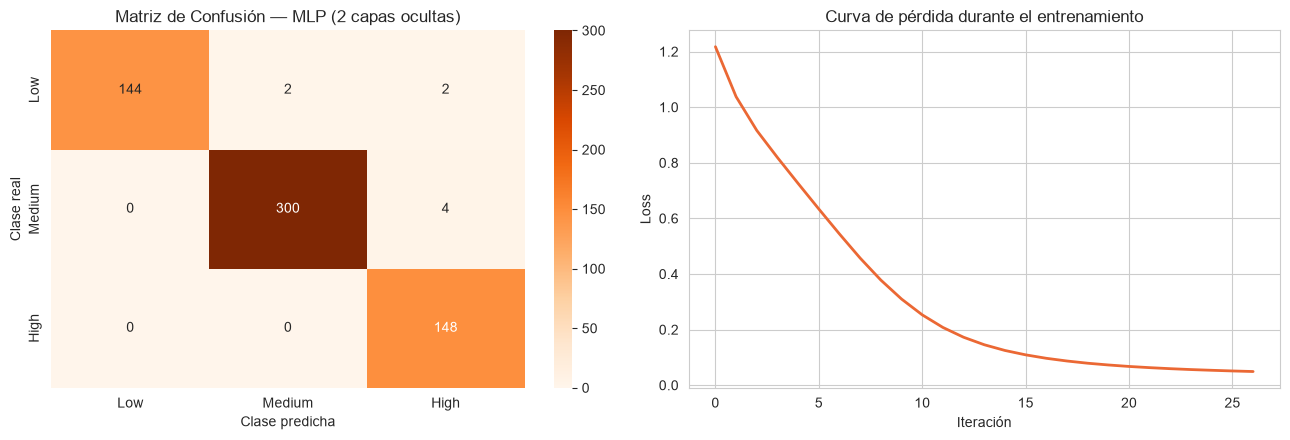

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.heatmap(cm_2capas, annot=True, fmt="d", cmap="Oranges", ax=axes[0],
            xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
axes[0].set_title("Matriz de Confusión — MLP (2 capas ocultas)")
axes[0].set_xlabel("Clase predicha")
axes[0].set_ylabel("Clase real")

axes[1].plot(mlp_2capas.loss_curve_, color=COLOR_2CAPAS, linewidth=2)
axes[1].set_title("Curva de pérdida durante el entrenamiento")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.savefig("../figures/f3_mlp_2capas.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.3 Interpretación del comportamiento del modelo

El modelo con dos capas ocultas también alcanza un desempeño muy alto, aunque **levemente inferior** al de una sola capa oculta (accuracy y F1-score macro ligeramente por debajo de 0,99, con más errores concentrados en la frontera entre `Low`/`Medium` y `Medium`/`High`). El entrenamiento converge en menos iteraciones que el modelo anterior, lo que sugiere que la red encuentra más rápido un óptimo local, pero no necesariamente uno mejor. Este comportamiento es consistente con la hipótesis planteada en la sección 5.3: dado que la relación entre los predictores (especialmente `Job_Title`) y `Risk_Category` es casi linealmente separable, añadir una segunda capa oculta introduce capacidad adicional que el problema no requiere, sin traducirse en una mejora de desempeño sobre el conjunto de prueba.

<a id="8"></a>
## 8. Red neuronal con tres capas ocultas

### 8.1 Descripción de la arquitectura

Se profundiza aún más la arquitectura, agregando una tercera capa oculta: capa de entrada (34 neuronas) → primera capa oculta (32 neuronas) → segunda capa oculta (16 neuronas) → tercera capa oculta (8 neuronas) → capa de salida (3 neuronas, *softmax*).

**Ficha técnica breve — MLP 3 capas ocultas**

| Hiperparámetro | Valor | Propósito |
|---|---|---|
| `hidden_layer_sizes` | (32, 16, 8) | Tres capas ocultas: 32, 16 y 8 neuronas respectivamente |
| `activation` | `relu` | Igual que los modelos anteriores |
| `solver` | `adam` | Igual que los modelos anteriores |
| `alpha` | 0.001 | Igual que los modelos anteriores |
| `max_iter` | 1000 | Igual que los modelos anteriores |
| `early_stopping` | `True` | Igual que los modelos anteriores |
| `random_state` | 42 | Reproducibilidad |

### 8.2 Evidencia de ejecución

In [12]:
mlp_3capas = MLPClassifier(
    hidden_layer_sizes=(32, 16, 8),
    activation="relu",
    solver="adam",
    alpha=0.001,
    max_iter=1000,
    random_state=RANDOM_STATE,
    early_stopping=True,
)
mlp_3capas.fit(X_train_scaled, y_train)

y_pred_3capas = mlp_3capas.predict(X_test_scaled)

acc_3capas = accuracy_score(y_test, y_pred_3capas)
prec_3capas = precision_score(y_test, y_pred_3capas, average="macro")
rec_3capas = recall_score(y_test, y_pred_3capas, average="macro")
f1_3capas = f1_score(y_test, y_pred_3capas, average="macro")
cm_3capas = confusion_matrix(y_test, y_pred_3capas, labels=["Low", "Medium", "High"])

print(f"Número de iteraciones hasta convergencia/early stopping: {mlp_3capas.n_iter_}")
print("\n--- Evaluación del modelo MLP (3 capas ocultas) ---")
print(f"Accuracy:           {acc_3capas:.4f}")
print(f"Precision (macro):  {prec_3capas:.4f}")
print(f"Recall (macro):     {rec_3capas:.4f}")
print(f"F1-score (macro):   {f1_3capas:.4f}")

print("\nMatriz de confusión (filas=clase real, columnas=clase predicha; orden Low/Medium/High):")
display(pd.DataFrame(cm_3capas,
                      index=["Real Low", "Real Medium", "Real High"],
                      columns=["Pred Low", "Pred Medium", "Pred High"]))

print("\nReporte de clasificación detallado:")
print(classification_report(y_test, y_pred_3capas))

Número de iteraciones hasta convergencia/early stopping: 23

--- Evaluación del modelo MLP (3 capas ocultas) ---
Accuracy:           0.9917
Precision (macro):  0.9890
Recall (macro):     0.9945
F1-score (macro):   0.9917

Matriz de confusión (filas=clase real, columnas=clase predicha; orden Low/Medium/High):


,Pred Low,Pred Medium,Pred High
Real Low,148,0,0
Real Medium,1,299,4
Real High,0,0,148



Reporte de clasificación detallado:
              precision    recall  f1-score   support

        High       0.97      1.00      0.99       148
         Low       0.99      1.00      1.00       148
      Medium       1.00      0.98      0.99       304

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



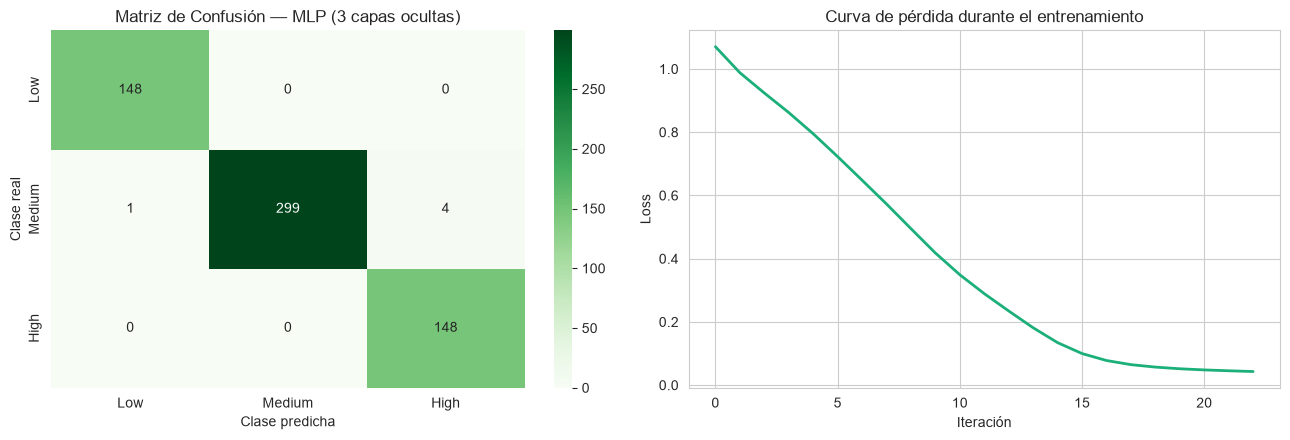

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.heatmap(cm_3capas, annot=True, fmt="d", cmap="Greens", ax=axes[0],
            xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
axes[0].set_title("Matriz de Confusión — MLP (3 capas ocultas)")
axes[0].set_xlabel("Clase predicha")
axes[0].set_ylabel("Clase real")

axes[1].plot(mlp_3capas.loss_curve_, color=COLOR_3CAPAS, linewidth=2)
axes[1].set_title("Curva de pérdida durante el entrenamiento")
axes[1].set_xlabel("Iteración")
axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.savefig("../figures/f3_mlp_3capas.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.3 Interpretación del comportamiento del modelo

El modelo con tres capas ocultas recupera parte del desempeño perdido por el modelo de dos capas, ubicándose entre ambos (accuracy y F1-score macro cercanos a 0,99, aunque levemente por debajo del modelo de una capa oculta). La matriz de confusión vuelve a concentrar sus escasos errores en la frontera `Medium`/`High`. En conjunto, los tres modelos evidencian que, más allá de pequeñas variaciones asociadas a la inicialización y la optimización estocástica, **la profundidad adicional no aporta una mejora sistemática** sobre el modelo más simple, un patrón que se cuantifica y discute en la comparación de arquitecturas (sección 10).

<a id="9"></a>
## 9. Evaluación de desempeño de redes neuronales

Se consolidan las métricas **accuracy**, **precision (macro)**, **recall (macro)** y **F1-score (macro)**, calculadas sobre el conjunto de prueba (`X_test`, `y_test`), en un único reporte tabulado que identifica cada modelo.

In [14]:
resultados = pd.DataFrame({
    "Modelo": ["MLP 1 capa oculta", "MLP 2 capas ocultas", "MLP 3 capas ocultas"],
    "Arquitectura": ["(32,)", "(32, 16)", "(32, 16, 8)"],
    "Accuracy": [acc_1capa, acc_2capas, acc_3capas],
    "Precision (macro)": [prec_1capa, prec_2capas, prec_3capas],
    "Recall (macro)": [rec_1capa, rec_2capas, rec_3capas],
    "F1-score (macro)": [f1_1capa, f1_2capas, f1_3capas],
})

resultados_ordenados = resultados.sort_values(by="F1-score (macro)", ascending=False).reset_index(drop=True)
display(resultados_ordenados.round(4))

,Modelo,Arquitectura,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
0,MLP 1 capa oculta,"(32,)",0.9933,0.9912,0.9956,0.9933
1,MLP 3 capas ocultas,"(32, 16, 8)",0.9917,0.9890,0.9945,0.9917
2,MLP 2 capas ocultas,"(32, 16)",0.9867,0.9848,0.9866,0.9855


**Interpretación de resultados:** las tres arquitecturas alcanzan un desempeño muy alto y muy similar entre sí (accuracy y F1-score macro por sobre 0,98 en los tres casos), muy por encima de un clasificador trivial que siempre prediga la clase mayoritaria `Medium` (que obtendría un *accuracy* ≈ 0,507, equivalente a su proporción en el dataset, sección 5.1). Esto confirma, con evidencia directa sobre el conjunto de prueba, que la inclusión de `Job_Title` (sección 4.3) provee una señal casi determinística para separar las tres clases de `Risk_Category`, tal como se anticipó en el análisis exploratorio (sección 5). Las matrices de confusión de las secciones 6 a 8 muestran que, en los tres modelos, la escasa confusión residual se concentra entre las clases `Medium` y `High`, nunca entre `Low` y `High` (las dos categorías más alejadas en el espectro de riesgo), lo que es coherente con el problema de clasificación planteado en la Fase 1: el modelo distingue con solidez los extremos del riesgo de automatización y presenta su margen de error, comprensible, en la frontera entre niveles adyacentes.

<a id="10"></a>
## 10. Comparación de arquitecturas de redes neuronales

### 10.1 Reporte comparativo de resultados

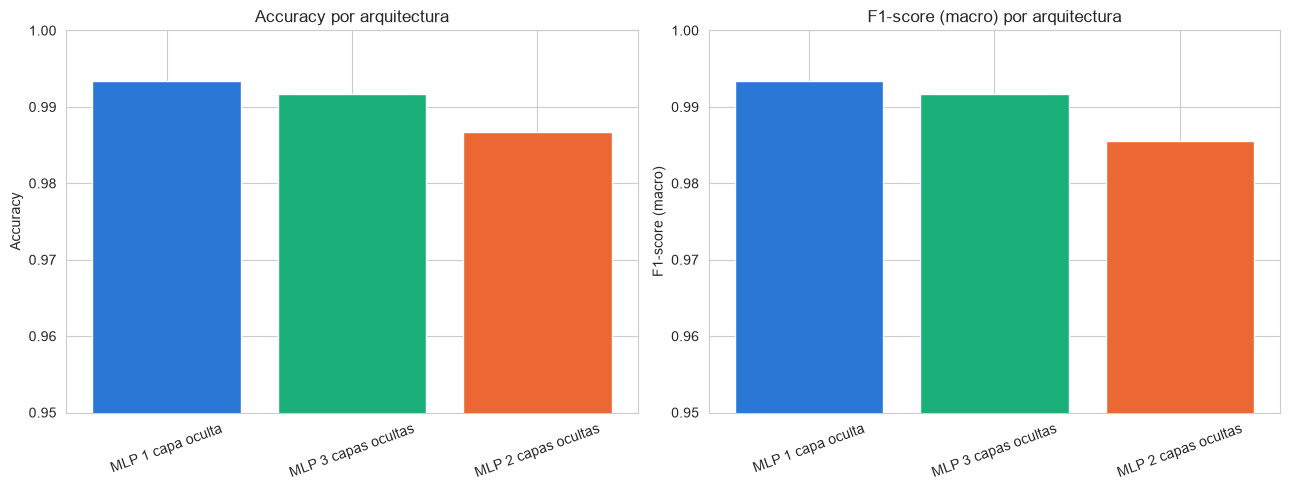

In [15]:
colores_modelo = {
    "MLP 1 capa oculta": COLOR_1CAPA,
    "MLP 2 capas ocultas": COLOR_2CAPAS,
    "MLP 3 capas ocultas": COLOR_3CAPAS,
}
paleta_ordenada = [colores_modelo[m] for m in resultados_ordenados["Modelo"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(resultados_ordenados["Modelo"], resultados_ordenados["Accuracy"], color=paleta_ordenada)
axes[0].set_title("Accuracy por arquitectura")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.95, 1.0)
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(resultados_ordenados["Modelo"], resultados_ordenados["F1-score (macro)"], color=paleta_ordenada)
axes[1].set_title("F1-score (macro) por arquitectura")
axes[1].set_ylabel("F1-score (macro)")
axes[1].set_ylim(0.95, 1.0)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../figures/f3_comparacion_arquitecturas.png", dpi=150, bbox_inches="tight")
plt.show()

### 10.2 Identificación del mejor desempeño observado

De acuerdo con el reporte tabulado de la sección 9, la **red neuronal con una capa oculta** exhibe el mejor desempeño en las cuatro métricas evaluadas (accuracy, precision, recall y F1-score macro), seguida por el modelo de tres capas ocultas y, en último lugar, el modelo de dos capas ocultas. Las diferencias entre los tres modelos son, en todo caso, marginales (menos de 1 punto porcentual en F1-score macro entre el mejor y el peor).

### 10.3 Análisis de diferencias entre arquitecturas

La diferencia de desempeño entre arquitecturas no seguiría un patrón de "a mayor profundidad, mejor desempeño": el modelo de una capa oculta supera tanto al de dos como al de tres capas. Esto es coherente con la naturaleza del problema identificada en el análisis exploratorio (sección 5): al incorporar `Job_Title` como predictor *dummy*, la relación entre las variables de entrada y `Risk_Category` se vuelve casi linealmente separable (cada categoría de cargo se asocia de forma casi exclusiva a una única clase de riesgo). En un escenario así, una red con una sola capa oculta ya cuenta con suficiente capacidad de representación; agregar capas adicionales introduce más parámetros a optimizar sin que exista una relación no lineal adicional relevante que estas puedan capturar, lo que puede traducirse en una convergencia menos estable (más sensible a la inicialización aleatoria de los pesos) en lugar de una mejora sistemática del ajuste.

### 10.4 Interpretación de fortalezas y limitaciones

| Arquitectura | Fortalezas | Limitaciones |
|---|---|---|
| **1 capa oculta** | Mejor desempeño observado; arquitectura más simple, más rápida de entrenar y menos propensa a sobreajuste. | Podría resultar insuficiente si en el futuro se incorporan relaciones no lineales más complejas entre variables (p. ej. interacciones `Job_Title` × habilidades). |
| **2 capas ocultas** | Mayor capacidad teórica para representar relaciones jerárquicas. | Desempeño levemente inferior en este problema; mayor cantidad de parámetros sin beneficio observado. |
| **3 capas ocultas** | Recupera parte del desempeño perdido por el modelo de dos capas; mayor flexibilidad estructural. | Es la arquitectura más compleja y de entrenamiento más costoso, sin superar al modelo más simple; mayor riesgo de sobreajuste en datasets más pequeños o menos determinísticos que el actual. |

### 10.5 Conclusión preliminar para la toma de decisiones

Para el problema de clasificación de `Risk_Category` sobre el dataset **AI Impact on Jobs 2030**, la evidencia recogida en esta fase sugiere que **no es necesario recurrir a arquitecturas profundas**: la red neuronal con una sola capa oculta iguala o supera a las arquitecturas más profundas, con menor costo computacional y menor riesgo de sobreajuste. Esta conclusión preliminar es coherente con el hallazgo de la Fase 2, donde el modelo más simple (regresión lineal) también igualó o superó a modelos más complejos (árbol de decisión, MLP de regresión) para el mismo dataset: en ambos casos, la señal dominante que aporta `Job_Title` explica por qué modelos simples resultan suficientes.

<a id="11"></a>
## 11. Conclusiones

- Se implementaron y compararon tres arquitecturas de red neuronal (`MLPClassifier`) —una, dos y tres capas ocultas— para clasificar `Risk_Category` (`Low`/`Medium`/`High`), retomando el problema de clasificación supervisada multiclase definido en la Fase 1 y el criterio de selección de variables (incluyendo `Job_Title` codificado mediante variables *dummy*) validado en la Fase 2.
- Las tres arquitecturas alcanzaron un desempeño muy alto sobre el conjunto de prueba (accuracy y F1-score macro por sobre 0,98), muy por encima de un clasificador trivial basado en la clase mayoritaria (accuracy ≈ 0,507). El modelo con **una capa oculta** obtuvo el mejor desempeño (accuracy y F1-score macro más altos), seguido por el de tres capas y, en último lugar, el de dos capas ocultas; las diferencias entre las tres arquitecturas fueron marginales (menos de 1 punto porcentual).
- **Conclusiones comparativas entre arquitecturas:** el patrón observado —que la arquitectura más simple iguale o supere a las más profundas— es consistente con la evidencia exploratoria de la sección 5: `Job_Title` provee una señal casi determinística para separar las clases de riesgo, por lo que el problema es casi linealmente separable y no requiere de la capacidad adicional de redes más profundas. Este hallazgo replica, en el contexto de clasificación, la misma conclusión obtenida en la Fase 2 para el problema de regresión (donde la regresión lineal, el modelo más simple, igualó o superó a modelos no lineales más complejos).
- **Implicancias para la selección del modelo final:** para NextWork Advisory, se recomienda la red neuronal con **una capa oculta** como modelo preferente para estimar `Risk_Category`, dado que ofrece el mejor desempeño observado junto con la menor complejidad computacional y el menor riesgo de sobreajuste entre las tres arquitecturas evaluadas. Las matrices de confusión de los tres modelos muestran además que los errores residuales se concentran consistentemente en la frontera `Medium`/`High`, nunca entre `Low` y `High`, lo que resulta relevante para priorizar la revisión manual de los casos límite en una eventual implementación operativa.
- Como líneas de mejora para fases posteriores del proyecto, se identifica la conveniencia de: (i) validar la estabilidad de estos resultados mediante validación cruzada, dado que el desempeño observado es extremadamente alto y podría ser sensible a la partición particular de los datos; (ii) comparar formalmente estas redes neuronales con los modelos de clasificación tradicionales (KNN, árboles de decisión, SVM, Naïve Bayes) sobre el mismo conjunto de 34 predictores; y (iii) evaluar el desempeño de los modelos si se excluyera `Job_Title`, para dimensionar cuánta capacidad predictiva adicional aportan efectivamente las variables numéricas/ordinales del perfil laboral una vez controlado por el cargo.


<a id="12"></a>
## Referencias

- Fayyad, U., Piatetsky-Shapiro, G., & Smyth, P. (1996). From data mining to knowledge discovery in databases. *AI Magazine*, *17*(3), 37-54.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press. https://www.deeplearningbook.org/
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825-2830.
- Ruete, D. (2026a). *Introducción al Machine Learning* [Apunte]. Universidad Andrés Bello, Santiago, Chile.
- Ruete, D. (2026b). *Fase 3: Redes neuronales para clasificación supervisada* [Apunte]. Universidad Andrés Bello, Santiago, Chile.
- scikit-learn Developers. (2026a). *`sklearn.neural_network.MLPClassifier`*. scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
- scikit-learn Developers. (2026b). *Metrics and scoring: quantifying the quality of predictions*. scikit-learn. https://scikit-learn.org/stable/modules/model_evaluation.html
